# Reproducible Fokker–Planck PINN workflow

This notebook uses a physics-informed neural network (PINN) to approximate
the solution of a one-dimensional Ornstein–Uhlenbeck Fokker–Planck equation.

The workflow includes model training, numerical evaluation, and comparison
with analytical results.

## Requirements

This workflow uses:

- Python 3.11
- PyTorch
- NumPy
- Matplotlib
- Jupyter Lab

The software environment is defined in `pyproject.toml` and `uv.lock`.

After cloning the repository, the environment can be recreated with:

    uv sync

Jupyter Lab can then be started with:

    uv run jupyter lab

In [11]:
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

torch.manual_seed(1234)
np.random.seed(1234)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.11.16 (main, Sep  1 2026, 14:08:36) [Clang 22.1.3 ]
PyTorch: 2.2.2
NumPy: 1.26.4
Matplotlib: 3.11.2


## Mathematical problem

The Ornstein–Uhlenbeck stochastic differential equation is

$$
dX_t = -\theta X_t\,dt + \sigma\,dW_t.
$$

The corresponding Fokker–Planck equation is

$$
\frac{\partial p}{\partial t}
=
\theta\frac{\partial(xp)}{\partial x}
+
D\frac{\partial^2p}{\partial x^2},
$$

where

$$
D=\frac{\sigma^2}{2}.
$$

The experiment uses $x\in[-5,5]$, $t\in[0,0.3]$,
$\theta=5$, and $D=0.1$.

The initial probability density is Gaussian:

$$
p(0,x)
=
\frac{1}{\sqrt{2\pi s_0^2}}
\exp\left(
-\frac{(x-m_0)^2}{2s_0^2}
\right),
$$

with $m_0=2$ and $s_0=0.3$.

Zero boundary conditions are imposed:

$$
p(t,-5)=p(t,5)=0.
$$

In [12]:
x_min = -5.0
x_max = 5.0
T_final = 0.3

N0 = 100
Nb = 100
Nf = 10000

theta = 5.0
D = 0.1

m0 = 2.0
s0 = 0.3


class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, t, x):
        tx = torch.cat([t, x], dim=1)
        return self.net(tx)


model = PINN()

## Training setup

Initial-condition, boundary-condition and collocation points are generated
inside the domain.

The PINN is trained using the initial and boundary conditions together
with the Fokker–Planck residual

$$
f(t,x)=p_t-\theta(xp)_x-Dp_{xx}.
$$

In [13]:
x0 = torch.linspace(x_min, x_max, N0).reshape(-1, 1)
t0 = torch.zeros(N0, 1)

p0 = 1 / np.sqrt(2*np.pi*s0**2) * torch.exp(
    -(x0 - m0)**2 / (2*s0**2)
)

t_left = T_final * torch.rand(Nb, 1)
x_left = x_min * torch.ones(Nb, 1)

t_right = T_final * torch.rand(Nb, 1)
x_right = x_max * torch.ones(Nb, 1)

t_bc = torch.cat([t0, t_left, t_right], dim=0)
x_bc = torch.cat([x0, x_left, x_right], dim=0)

p_bc = torch.cat(
    [p0, torch.zeros(Nb, 1), torch.zeros(Nb, 1)],
    dim=0
)

t_col = T_final * torch.rand(Nf, 1)
x_col = (x_max - x_min) * torch.rand(Nf, 1) + x_min

In [14]:
def fokkerplanck_residual(t, x):
    t = t.clone().detach().requires_grad_(True)
    x = x.clone().detach().requires_grad_(True)

    p = model(t, x)

    p_t = torch.autograd.grad(
        p, t,
        grad_outputs=torch.ones_like(p),
        create_graph=True
    )[0]

    p_x = torch.autograd.grad(
        p, x,
        grad_outputs=torch.ones_like(p),
        create_graph=True
    )[0]

    p_xx = torch.autograd.grad(
        p_x, x,
        grad_outputs=torch.ones_like(p_x),
        create_graph=True
    )[0]

    xp = x * p

    xp_x = torch.autograd.grad(
        xp, x,
        grad_outputs=torch.ones_like(xp),
        create_graph=True
    )[0]

    return p_t - theta * xp_x - D * p_xx

## Model training

The loss combines the initial/boundary-condition error with the PDE
residual:

$$
L=L_{\mathrm{data}}+L_{\mathrm{PDE}}.
$$

The model is first trained with Adam and then refined with L-BFGS.

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = []

for epoch in range(10000):
    optimizer.zero_grad()

    p_pred = model(t_bc, x_bc)
    loss_data = torch.mean((p_pred - p_bc) ** 2)
    
    f = fokkerplanck_residual(t_col, x_col)
    loss_pde = torch.mean(f ** 2)
    
    loss = loss_data + loss_pde
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}  |  loss: {loss.item():.4e}")

# L-BFGS fine-tuning
use_lbfgs = True

if use_lbfgs:
    optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0)

    def closure():
        optimizer.zero_grad()

        p_pred = model(t_bc, x_bc)
        loss_bc = torch.mean((p_pred - p_bc) ** 2)

        f = fokkerplanck_residual(t_col, x_col)
        loss_pde = torch.mean(f ** 2)

        loss = loss_bc + loss_pde
        loss.backward()

        return loss

    for epoch in range(250):
        loss = optimizer.step(closure)
        loss_history.append(loss.item())

        if epoch % 50 == 0:
            print(f"L-BFGS epoch {epoch:5d}  |  loss: {loss.item():.4e}")        

Epoch     0  |  loss: 7.9198e-02
Epoch   500  |  loss: 3.0701e-02
Epoch  1000  |  loss: 3.0262e-02
Epoch  1500  |  loss: 2.9994e-02
Epoch  2000  |  loss: 2.9739e-02
Epoch  2500  |  loss: 3.0069e-02
Epoch  3000  |  loss: 2.8925e-02
Epoch  3500  |  loss: 2.8411e-02
Epoch  4000  |  loss: 2.7592e-02
Epoch  4500  |  loss: 2.6850e-02
Epoch  5000  |  loss: 2.5937e-02
Epoch  5500  |  loss: 2.5064e-02
Epoch  6000  |  loss: 2.4071e-02
Epoch  6500  |  loss: 2.2210e-02
Epoch  7000  |  loss: 1.9800e-02
Epoch  7500  |  loss: 1.8083e-02
Epoch  8000  |  loss: 1.5831e-02
Epoch  8500  |  loss: 1.3887e-02
Epoch  9000  |  loss: 1.1629e-02
Epoch  9500  |  loss: 1.0179e-02
L-BFGS epoch     0  |  loss: 8.7769e-03
L-BFGS epoch    50  |  loss: 3.0793e-05
L-BFGS epoch   100  |  loss: 4.2265e-06
L-BFGS epoch   150  |  loss: 4.0869e-06
L-BFGS epoch   200  |  loss: 4.0869e-06


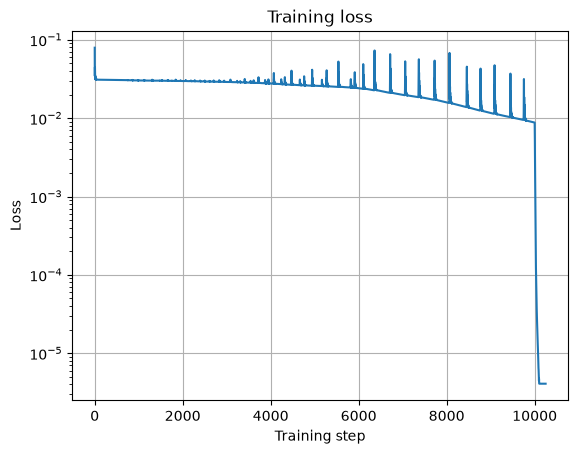

In [16]:
plt.figure()
plt.semilogy(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

## Evaluation

The trained model is evaluated on a regular grid.

Probability mass, minimum density, mean and variance are calculated.
The predicted mean and variance are also compared with their analytical
Ornstein–Uhlenbeck values.

In [23]:
# evaluate on a grid
nt, nx = 100, 256
t_vals = np.linspace(0, T_final, nt)
x_vals = np.linspace(x_min, x_max, nx)

T, X = np.meshgrid(t_vals, x_vals, indexing="ij")

t_flat = torch.tensor(T.reshape(-1, 1), dtype=torch.float32)
x_flat = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)

model.eval()

with torch.no_grad():
    P_pred = model(t_flat, x_flat).numpy().reshape(nt, nx)

In [24]:
# probability mass
mass = np.trapz(P_pred, x_vals, axis=1)

# check negative density
min_density = np.min(P_pred, axis=1)

# mean and variance
mean = np.trapz(X * P_pred, x_vals, axis=1) / mass

variance = (
    np.trapz(
        (X - mean[:, None])**2 * P_pred,
        x_vals,
        axis=1
    )
    / mass
)

In [25]:
print(f"Initial mass: {mass[0]:.6f}")
print(f"Final mass: {mass[-1]:.6f}")
print(f"Max mass error: {np.max(np.abs(mass - 1)):.6e}")

print()

print(
    f"Minimum density over whole grid: "
    f"{np.min(P_pred):.6e}"
)

Initial mass: 0.999838
Final mass: 0.996219
Max mass error: 3.781429e-03

Minimum density over whole grid: -4.100740e-03


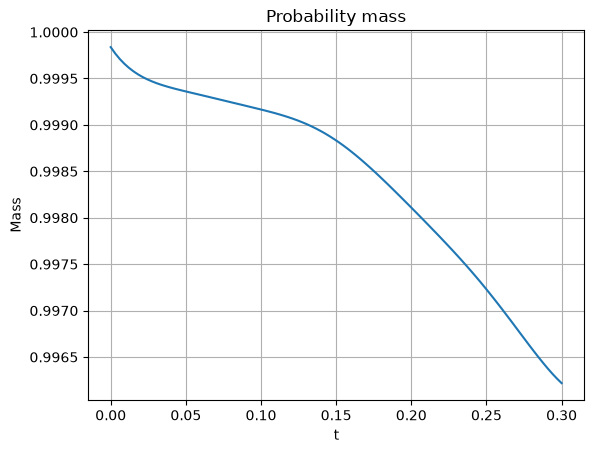

In [26]:
plt.figure()

plt.plot(t_vals, mass)

plt.xlabel("t")
plt.ylabel("Mass")
plt.title("Probability mass")
plt.grid(True)

plt.show()


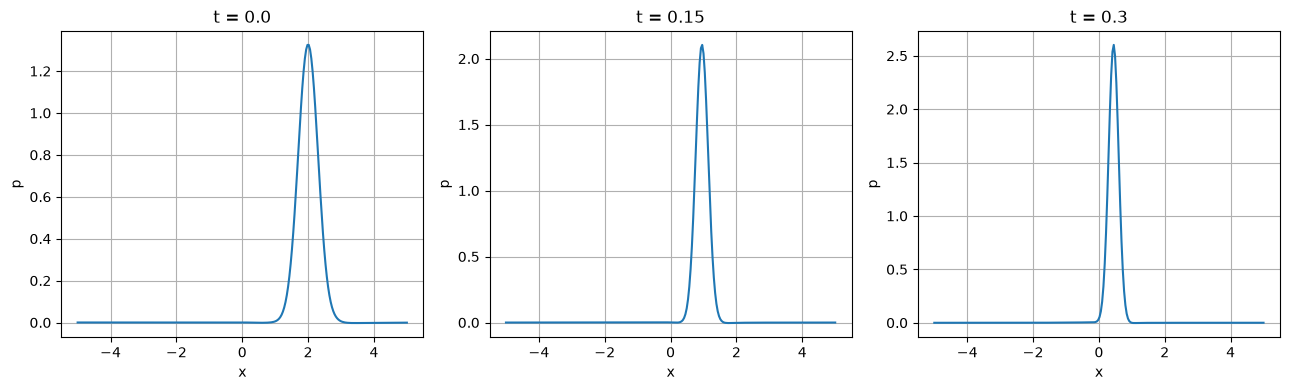

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, t_snap in zip(axes, [0.0, 0.15, 0.3]):
    idx = np.argmin(np.abs(t_vals - t_snap))

    ax.plot(x_vals, P_pred[idx, :])
    ax.set_title(f"t = {t_snap}")
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Analytical comparison

For the Ornstein–Uhlenbeck process, the exact mean is

$$
m(t)=m_0e^{-\theta t},
$$

and the exact variance is

$$
s^2(t)
=
s_0^2e^{-2\theta t}
+
\frac{D}{\theta}
\left(1-e^{-2\theta t}\right).
$$

These analytical expressions are used as reference values for evaluating
the PINN result.

In [28]:
mean_exact = m0 * np.exp(-theta * t_vals)

variance_exact = (
    s0**2 * np.exp(-2 * theta * t_vals)
    + (D / theta) * (1 - np.exp(-2 * theta * t_vals))
)

In [29]:
print(
    f"Final mean error: "
    f"{abs(mean[-1] - mean_exact[-1]):.6e}"
)

print(
    f"Final variance error: "
    f"{abs(variance[-1] - variance_exact[-1]):.6e}"
)

mean_error = np.abs(mean - mean_exact)
variance_error = np.abs(variance - variance_exact)

print(f"Max mean error: {np.max(mean_error):.6e}")
print(f"Max variance error: {np.max(variance_error):.6e}")

Final mean error: 1.726922e-03
Final variance error: 3.625539e-02
Max mean error: 1.510388e-02
Max variance error: 3.625539e-02


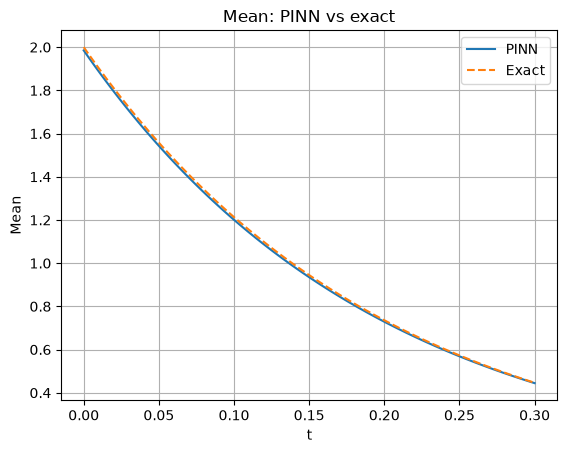

In [30]:
plt.figure()

plt.plot(t_vals, mean, label="PINN")
plt.plot(t_vals, mean_exact, "--", label="Exact")

plt.xlabel("t")
plt.ylabel("Mean")
plt.title("Mean: PINN vs exact")
plt.grid(True)
plt.legend()

plt.show()

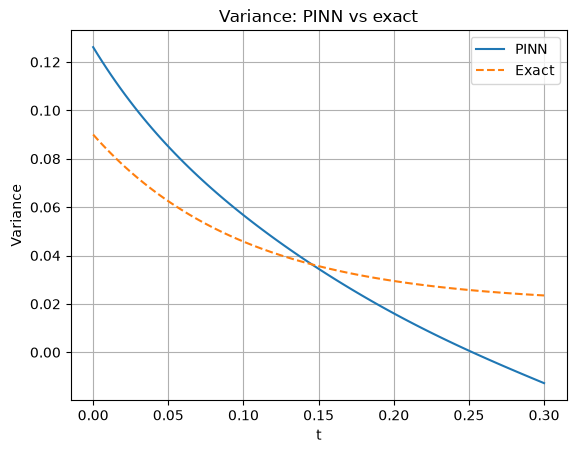

In [31]:
plt.figure()

plt.plot(t_vals, variance, label="PINN")
plt.plot(t_vals, variance_exact, "--", label="Exact")

plt.xlabel("t")
plt.ylabel("Variance")
plt.title("Variance: PINN vs exact")
plt.grid(True)
plt.legend()

plt.show()

## Dependencies and version pinning

This workflow uses Python 3.11 together with PyTorch, NumPy, Matplotlib
and Jupyter Lab.

The project uses `pyproject.toml` to specify its direct dependencies and
`uv.lock` to store the complete resolved environment.

PyTorch 2.2.2 and NumPy 1.26.4 are explicitly pinned. PyTorch 2.2.2 was
chosen because it provides a compatible build for the Intel macOS system
used to develop this workflow.

Version pinning reduces the chance that future package updates change
APIs or numerical behaviour and makes the software environment easier
for another user to reproduce.

## FAIR data principles

The FAIR principles describe research outputs that are Findable,
Accessible, Interoperable and Reusable.

### Findable

The workflow is stored in a GitHub repository with a descriptive name,
README file and relevant keywords.

### Accessible

The notebook and source code are available through the repository.
No external dataset is required because the initial condition and
training points are generated directly by the workflow.

### Interoperable

The workflow uses Python, Jupyter Notebook and commonly used open-source
libraries including PyTorch, NumPy and Matplotlib.

The mathematical model and parameter values are documented in the
notebook rather than appearing only inside the source code.

### Reusable

The repository contains the source code, model parameters, random seed,
dependency versions and instructions required to repeat the experiment.

A software licence is included so that the conditions for reuse are
clearly stated.

## Running the workflow

Clone the repository and enter the project directory.

Recreate the software environment with:

    uv sync

Start Jupyter Lab with:

    uv run jupyter lab

Open `fokker_planck_pinn.ipynb` and run all cells from top to bottom.

The notebook uses a fixed random seed to improve reproducibility.